# Model 2: DAE implementation

## Problem Statement

This part is meant to rewrite the system of equations we already know and love as model 2 (and which we h_gave also solved using our own IMEX Method), as a DAE, and solve it with an automatic solver. The goal is to solve for:

\begin{equation}
\left\{\begin{aligned}
    \partial_t\rho_g&= D(\Delta\rho_g)-\mathbf{v}\cdot(\nabla\rho_g)-\dot m_a(\rho_g, \rho_s) \\
    \partial_t\rho_s&=\dot m_a(\rho_g, \rho_s)
\end{aligned}\right.
\end{equation}
Where $\rho$ is the density at that point and $\rho_s$ is the saturation of the metal. $D$ is the diffusivity, and $\mathbf{v}$ the velocity ($\mathbf v=(v_x, v_y)$).

### Mathematical Discretizations

Under initial condition and boundary conditions are (since there is no coupling effects of saturation of the metal I am pretty sure we do not need boundary conditions there, but I'll look into this and phrase it more rigorous):

\begin{equation}
\left\{ \begin{aligned}
    \rho_g(\mathbf{x}, 0)  &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_s(\mathbf{x},0) &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_g(\mathbf{x}, t)  &= 1, &\forall \mathbf{x}\in\partial\Omega_1,\forall t\geq 0, \\
    \partial_\mathbf{n}\rho_g(\mathbf{x}, t)  &= 0, &\forall \mathbf{x}\in\partial\Omega_2,\forall t\geq 0. 
\end{aligned}\right.
\end{equation}

where $\mathbf x = (x, y)$. the function for calculating adsorption is simplified into:

$$
\dot m(\rho_g, \rho_s) = M_a\log \left(\frac{RT\rho_g}{p_{eqa}}\right)(\rho_{sat}-\rho_s)
$$

We will be expanding $\rho_g^n$, and $\rho_s^n$, (the values at their respective timesteps) into Lagrange polynomials:

\begin{equation*}
\begin{aligned}
\rho_g^n&=\sum{\rho_g^{n,i}\psi^i},\\
\rho_s^n&=\sum{\rho_s^{n,i}\psi^i}.
\end{aligned}
\end{equation*}

we want to solve for $\rho_g$ and $\rho_s$, so our solution vector $\mathbf{u^n}$ becomes:

$$
\mathbf{u^n} = \begin{pmatrix}\rho_g^{n, 1} \\ \vdots \\ \rho_g^{n, N} \\ \rho_s^{n, 1} \\ \vdots \\ \rho_s^{n, N}
\end{pmatrix}
$$

if we discretize, we get:

$$
M\dot{\mathbf{u}}=\begin{pmatrix}D-C & 0 \\ 0 & 0\end{pmatrix}\mathbf{u}+\begin{pmatrix}-\dot m_a(\rho_g, \rho_s) \\ \dot m_a(\rho_g, \rho_s)\end{pmatrix}
$$

which simply becomes:

$$
res(\mathbf{u}, \mathbf{du}) = M{\mathbf{du}}-L\mathbf{u}-\mathbf{f}(\mathbf{u})
$$

Where we have again:

$$
L = \begin{pmatrix}D-C & 0 \\ 0 & 0\end{pmatrix}, \\ \mathbf{f}(\mathbf{u}) = \begin{pmatrix}-\dot m_a(\rho_g, \rho_s) \\ \dot m_a(\rho_g, \rho_s)\end{pmatrix},\\
M_{ij}=\int \psi^i\psi^j dx,\\
C_{ij}=\int (\mathbf{v}\cdot\nabla\psi^i)\psi^j \,dx,\\
D_{ij}=\int (\nabla \cdot \psi^i)(\nabla \cdot \psi^j)\, dx$$

In [66]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra, DifferentialEquations

In [67]:
include(joinpath(@__DIR__, "FEMDAESolver.jl"))
using .FEMDAESolver

In [68]:
Constants(
    1.0,        # R::Float64
    1.0,        # T::Float64
    1.0,        # A::Float64
    1.0,        # μ::Float64
    1.0,        # velocity::Float64
    0.4,        # ϵ::Float64
    1.0,        # MA::Float64
    1.0,        # rho_sat::Float64
    1.0,        # p_eqa::Float64
    1.0         # K::Float64    
)

folder_name = "c. dae"

"c. dae"

## Definitions

In [173]:
# Time integration parameters
dt = 1e-4
dt_save = 1e-1
T1 = 4.0;

save_every = Int(round(dt_save / dt))  # = 100 steps
nsteps = Int(round(T1 / dt_save))

# Constants
R = 1.0;        # ideal gas constant - should be 8.314 J/(mol*K)
T = 1.0;        # temperature
A = 1.0;        # absorption coefficient 1/s
μ = 0.01;        # dynamic viscosity
velocity = 0.5; # artificial diffusion coefficient
ϵ = 0.4;        # porosity unitless

MA = 1.0;       # mass transfer coefficient
rho_sat = 1.0;  # saturation density
p_eqa = 1.0;    # equilibrium pressure
K = 1.0;        # permeability

name = "c. dae";

## grid

In [174]:
# generates grid
grid = generate_grid(Line, (100,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(3)
fr = FacetQuadratureRule{RefLine}

# rho_g, rho_s
ip_rho_g = Lagrange{RefLine, 1}()
cellvalues_rho_g = CellValues(qr, ip_rho_g);

ip_rho_s = Lagrange{RefLine, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefLine, 1}()
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)

left =  getfacetset(grid, "left")
right = getfacetset(grid, "right")

OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((100, 2))

In [175]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :rho_g, ip_rho_g)
add!(dh, :rho_s, ip_rho_s)
close!(dh);



In [176]:
# constraint handler
ch = ConstraintHandler(dh)
    
inlet_ρ = Dirichlet(
    :rho_g,
    left,
    (x, t) -> 2 
)
    
# add the constraints to the constraint handler
# ρ_s is not constrained, since it is not coupled spacially yay
add!(ch, inlet_ρ)

close!(ch)
update!(ch, 0.0)

In [177]:
# for debugging purpuses

const rho_g_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_g)]
    for cell in CellIterator(dh)
]...)))

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [178]:
function doassemble_M!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho_g::CellValues, 
    cellvalues_rho_s::CellValues,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho_g  = getnbasefunctions(cellvalues_rho_g)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rhog_dofs = dof_range(dh, :rho_g)
    rhos_dofs  = dof_range(dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        Ferrite.reinit!(cellvalues_rho_g, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_g)
            dx = getdetJdV(cellvalues_rho_g, q_point)
            for i in 1:n_basefuncs_rho_g
                psi_i = shape_value(cellvalues_rho_g, q_point, i)
                for j in 1:n_basefuncs_rho_g
                    psi_j = shape_value(cellvalues_rho_g, q_point, j)
                    # pim pam pet
                    Me[rhog_dofs[i], rhog_dofs[j]] += ϵ * psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += (1-ϵ) * psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M! (generic function with 1 method)

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [179]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_rho_g::CellValues, 
    cellvalues_rho_s::CellValues, 
    dh::DofHandler
    )

    assembler = start_assemble(D)

    # number of basis functions per field
    n_basefuncs_rho_g  = getnbasefunctions(cellvalues_rho_g)

    for cell in CellIterator(dh)

        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        De = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        Ferrite.reinit!(cellvalues_rho_g, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho_g)
            dx = getdetJdV(cellvalues_rho_g, q_point)

            for i in 1:n_basefuncs_rho_g
                dpsi_i = shape_gradient(cellvalues_rho_g, q_point, i)

                for j in 1:n_basefuncs_rho_g
                    dpsi_j = shape_gradient(cellvalues_rho_g, q_point, j)
                    # D∫ (∇ψ^i) ⋅ (∇ψ^j)dx
                    De[i, j] += μ * (dpsi_j ⋅ dpsi_i) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end

    return D
end


doassemble_D! (generic function with 1 method)

$$C_{ij}=\int (\mathbf{v}\cdot\nabla\psi^i)\psi^j \,dx$$

In [180]:
function doassemble_C!(
    K::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rhos::CellValues, 
    dh::DofHandler
    )

    n_basefuncs_rho = getnbasefunctions(cellvalues_rho)
    Ce = zeros(n_basefuncs_rho, n_basefuncs_rho)

    assembler = start_assemble(C)

    for cell in CellIterator(dh)
        
        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Ce = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        Ferrite.reinit!(cellvalues_rho, cell)
        fill!(Ce, 0)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)
                    # -v \psi^i(\partial_x\psi^j)dx
                    Ce[i, j] += (velocity ⋅ dpsi_j) *  psi_i * dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Ce)
    end

    return C
end


doassemble_C! (generic function with 1 method)

$$\dot M = \int \phi^k \log \left( \frac{RT\rho_g}{p_{eq}}\right)(\rho_{sat}-\rho_s)dx$$

In [181]:
struct RHSparams
    A::Float64
    R::Float64
    T::Float64
    p_eqa::Float64
    rho_sat::Float64
    dh::DofHandler
    cellvalues_rhog::CellValues
    cellvalues_rhos::CellValues
    M::SparseMatrixCSC          # {Float64,Int} ?
    rhs::Vector{Float64}        # Can start as zeros, but we do not want to allocate each time step, so we will reuse it
    rhsL::SparseMatrixCSC       # Linear part of right-hand side
    assemble_rhs!::Function     # Complete assembly of the right-hand side, including the nonlinear part
end

In [182]:
function assemble_rhs!(
    N::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams
)

    N .= params.rhsL * u # This line computes the linear part of the right-hand side by multiplying the linear part of the right-hand side matrix (params.rhsL) with the solution vector (u). The result is stored in N, which represents the complete right-hand side vector for the system of equations.

    # now for the non-linear part:

    rhog_dofs = dof_range(params.dh, :rho_g)
    rhos_dofs = dof_range(params.dh, :rho_s)

    for cell in CellIterator(params.dh)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            # dot m =       A*log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            for i in 1:length(rhog_local)
                ψ = shape_value(params.cellvalues_rhog,q,i)
                N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end
        end
    end
    return N
end

assemble_rhs! (generic function with 1 method)

In [183]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
rhs    = similar(u)

# Initialization of matrices
# Assemble linear matrices
M     = allocate_matrix(dh);
D     = allocate_matrix(dh);
K     = allocate_matrix(dh);
C     = allocate_matrix(dh);
rhsL  = allocate_matrix(dh);

doassemble_M!(M, cellvalues_rho_g, cellvalues_rho_s, dh)
doassemble_D!(D, cellvalues_rho_g, cellvalues_rho_s, dh)
doassemble_C!(C, cellvalues_rho_g, cellvalues_rho_s, dh)
# doassemble_K!(K, cellvalues_rho_g, cellvalues_rho_s, dh)

# Linear parts of rhs
rhsL = - D - C

# Initial condition
apply_analytical!(u, dh, :rho_g, x -> 1.0)
apply_analytical!(u, dh, :rho_s, x -> 0.0)

# Initial BC application
update!(ch, 0.0)
apply!(u, ch);


In [184]:
C[rho_g_global, rho_g_global][3,2]

-0.25000000000000006

In [185]:
params = RHSparams(
    A, 
    R, 
    T, 
    p_eqa, 
    rho_sat, 
    dh, 
    cellvalues_rho_g, 
    cellvalues_rho_s, 
    M,
    rhs,
    rhsL,
    assemble_rhs!    
)

RHSparams(1.0, 1.0, 1.0, 1.0, 1.0, DofHandler{1, Grid{1, Line, Float64}}(SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}[SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}(DofHandler{1, Grid{1, Line, Float64}}(#= circular reference @-3 =#), OrderedCollections.OrderedSet{Int64}([1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  91, 92, 93, 94, 95, 96, 97, 98, 99, 100]), [:rho_g, :rho_s], Interpolation[Lagrange{RefLine, 1}(), Lagrange{RefLine, 1}()], Int64[], 4)], [:rho_g, :rho_s], [1, 2, 3, 4, 2, 5, 4, 6, 5, 7  …  196, 198, 197, 199, 198, 200, 199, 201, 200, 202], [1, 5, 9, 13, 17, 21, 25, 29, 33, 37  …  361, 365, 369, 373, 377, 381, 385, 389, 393, 397], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1], true, Grid{1, Line, Float64}(Line[Line((1, 2)), Line((2, 3)), Line((3, 4)), Line((4, 5)), Line((5, 6)), Line((6, 7)), Line((7, 8)), Line((8, 9)), Line((9, 10)), Line((10, 11))  …  Line((91, 92)), Line((92, 93)), Line((93, 94)), Line((94, 95)), Line((95, 96)), Line((96, 97)), Line((

In [186]:
function res!(res, du, u, params, t)

    params.assemble_rhs!(params.rhs, u, params)

    mul!(res, params.M, du)      # res = M*du
    res .-= params.rhs

    update!(ch, t)
    for k in 1:length(ch.prescribed_dofs)
        dof = ch.prescribed_dofs[k]
        value = ch.inhomogeneities[k]
        res[dof] = u[dof] - value
    end
end

res! (generic function with 1 method)

In [187]:
using DifferentialEquations

In [188]:
update!(ch, 0.0)
apply!(u, ch)          # enforce initial state


202-element Vector{Float64}:
 2.0
 1.0
 0.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 ⋮
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0

In [189]:
res!(du, du, u, params, 0.0)

In [190]:
update!(ch, 0.0)
apply!(u, ch)          # enforce initial state

dt = 1e-7

params.assemble_rhs!(params.rhs, u, params)

B = params.rhs * dt + (params.M * u)
A = copy(params.M)
apply!(A, B, ch)

u_new = A \ B
du = ( u_new - u) / dt

for k in eachindex(ch.prescribed_dofs)
    dof = ch.prescribed_dofs[k]
    println(
        "DOF ", dof,
        " u=", u[dof],
        " du=", du[dof]
    )
end

DOF 1 u=2.0 du=0.0


In [191]:
params.rhs[rho_g_global]

101-element Vector{Float64}:
 -0.7524999219750447
  1.2486369177592045
  0.0
  0.0
  0.0
 -2.220446049250313e-16
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  ⋮
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0

In [192]:
du[rho_g_global]

101-element Vector{Float64}:
    0.0
  501.8568806325341
 -134.4721458795828
   36.03170289023794
   -9.654665690250752
    2.586959875205963
   -0.6931738127935461
    0.18573536042509886
   -0.04976764111930265
    0.013335195170327552
   -0.0035731573255759486
    0.0009574230297459962
   -0.00025654034452315955
    ⋮
   -2.220446049250313e-9
   -2.220446049250313e-9
   -2.220446049250313e-9
   -2.220446049250313e-9
   -2.220446049250313e-9
   -3.3306690738754696e-9
    0.0
    0.0
   -2.220446049250313e-9
   -2.220446049250313e-9
   -3.3306690738754696e-9
    2.220446049250313e-9

In [193]:
du[rho_g_global]

101-element Vector{Float64}:
    0.0
  501.8568806325341
 -134.4721458795828
   36.03170289023794
   -9.654665690250752
    2.586959875205963
   -0.6931738127935461
    0.18573536042509886
   -0.04976764111930265
    0.013335195170327552
   -0.0035731573255759486
    0.0009574230297459962
   -0.00025654034452315955
    ⋮
   -2.220446049250313e-9
   -2.220446049250313e-9
   -2.220446049250313e-9
   -2.220446049250313e-9
   -2.220446049250313e-9
   -3.3306690738754696e-9
    0.0
    0.0
   -2.220446049250313e-9
   -2.220446049250313e-9
   -3.3306690738754696e-9
    2.220446049250313e-9

In [194]:
differential_vars = trues(length(u))
tspan = (0.0, T1)


prob = DAEProblem(
    res!,
    du,
    u,
    tspan,
    params;
    differential_vars=differential_vars
)

sol = solve(prob, saveat=0.05, reltol=1e-8, abstol=1e-8)

retcode: Success
Interpolation: 1st order linear
t: 81-element Vector{Float64}:
 0.0
 0.05
 0.1
 0.15
 0.2
 0.25
 0.3
 0.35
 0.4
 0.45
 0.5
 0.55
 0.6
 ⋮
 3.45
 3.5
 3.55
 3.6
 3.65
 3.7
 3.75
 3.8
 3.85
 3.9
 3.95
 4.0
u: 81-element Vector{Vector{Float64}}:
 [2.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0]
 [1.99999999992911, 1.9647149637203662, 0.056223758559325585, 0.05021172779350574, 1.919233535726294, 0.043481808314121136, 1.862781761176343, 0.03698757394490578, 1.7955537840542277, 0.03088209756901074  …  1.0, 3.009059674211086e-21, 1.0, -2.8829640484460078e-21, 1.0, 2.8038615446965034e-21, 1.0, -2.8736349865640746e-21, 1.0, 3.2074411478053237e-21]
 [1.9999999986131216, 1.9830132994159633, 0.10919556958686602, 0.10263823044804579, 1.9636921327937868, 0.09517828737341, 1.9415109694290904, 0.08766945520345505, 1.915957198526775, 0.08021611134452142  …  1.0000000000000002, -4.530411124380227e-18, 1.0, -5.144807486432307e-18, 1.0

In [195]:
sol.alg

Sundials.IDA{:Dense, Nothing, Nothing}(0, 0, 0, 5, 7, 0.33, 3, 10, 0.0033, 5, 4, 10, 100, true, false, nothing, nothing)

## Plotting/animating

In [169]:
using Plots

In [196]:
U = Array(sol);

In [62]:
# double gif plot
foldername = name

U = Array(sol)

# sol_v = U[v_global, :]
sol_ρ = U[rho_g_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

anim = @animate for k in 1:size(sol_ρ, 2)

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density",
        color=:blue,
        xlabel="x",
        ylabel="density",
        title="t = $(round(discrete_t[k], digits=4))",
        ylims=(0, ρmax),
        legend=:topright
    )

    plot!(
        p1,
        discrete_x,
        sol_ρ_s[:, k],
        label="density solid",
        color=:red,
    )

    # plot!(
    #     p1,
    #     discrete_x,
    #     sol_ρ[:,k],
    #     seriestype=:scatter
    # )

    p2 = plot(
        [0,0], [1,1]
    )

    plot(p1, layout=(2,1), size=(600, 300))
end;

[ Info: Saved animation to c:\Users\noudh\uni\MEP\Model 2\c. dae\B.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\Model 2\\c. dae\\B.gif")
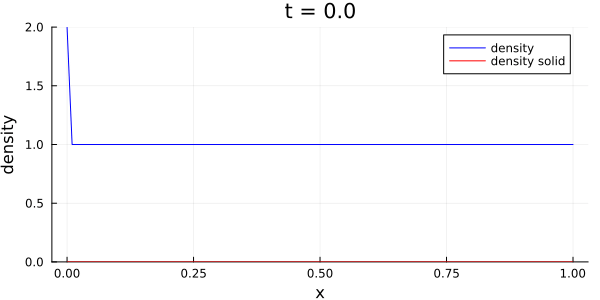

In [63]:
gif(anim, joinpath(foldername, "B.gif"), fps=20)

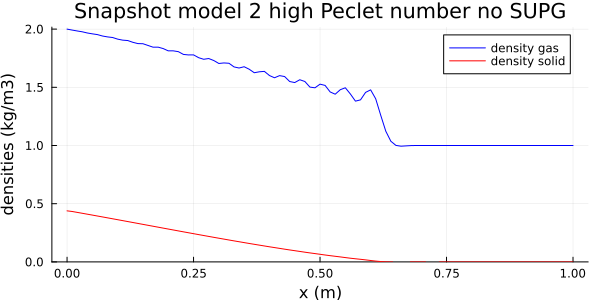

In [209]:
# double gif plot
foldername = name
k = 11
# U = Array(sol)

# sol_v = U[v_global, :]
sol_ρ = U[rho_g_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

p1 = plot(
    discrete_x,
    sol_ρ[:, k],
    label="density gas",
    color=:blue,
    xlabel="x (m)",
    ylabel="densities (kg/m3)",
    title="Snapshot model 2 high Peclet number no SUPG",
    ylims=(0, ρmax),
    legend=:topright
)

plot!(
    p1,
    discrete_x,
    sol_ρ_s[:, k],
    label="density solid",
    color=:red,
)

# plot!(
#     p1,
#     discrete_x,
#     sol_ρ[:,k],
#     seriestype=:scatter
# )

p2 = plot(
    [0,0], [1,1]
)

plot(p1, layout=(2,1), size=(600, 300))


In [210]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_2_result_high_Peclet.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_2_result_high_Peclet.png"

In [208]:
U = U3;

In [ ]:
Ulp = U;

202×81 Matrix{Float64}:
 2.0   2.0           2.0          …  2.0       2.0       2.0
 1.0   1.96471       1.98301         1.99984   1.99985   1.99985
 0.0   0.0562238     0.109196        0.988953  0.989573  0.990158
 0.0   0.0502117     0.102638        0.988767  0.989397  0.989992
 1.0   1.91923       1.96369         1.99967   1.99969   1.9997
 0.0   0.0434818     0.0951783    …  0.988564  0.989206  0.989812
 1.0   1.86278       1.94151         1.99949   1.99952   1.99955
 0.0   0.0369876     0.0876695       0.988355  0.989008  0.989625
 1.0   1.79555       1.91596         1.99932   1.99935   1.99939
 0.0   0.0308821     0.0802161       0.988139  0.988804  0.989432
 1.0   1.71885       1.88657      …  1.99913   1.99918   1.99923
 0.0   0.0252702     0.0728871       0.987917  0.988595  0.989235
 1.0   1.63501       1.85301         1.99894   1.999     1.99906
 ⋮                                ⋱                      ⋮
 1.0   1.0           1.0          …  1.93777   1.9411    1.94426
 0.0  

In [172]:
U3 = U

202×81 Matrix{Float64}:
 2.0   2.0           2.0          …  2.0       2.0       2.0
 1.0   2.001         1.9893          2.0       1.99965   2.00001
 0.0   0.0562846     0.109252        0.988954  0.989574  0.990159
 0.0   0.0507301     0.103499        0.988783  0.989413  0.990007
 1.0   1.97324       1.96437         1.99917   1.99998   1.99979
 0.0   0.0415284     0.0944746    …  0.988567  0.989209  0.989814
 1.0   1.90768       1.9719          1.99981   1.99978   1.9991
 0.0   0.03269       0.0854448       0.988345  0.988999  0.989616
 1.0   1.99877       1.96305         1.99986   1.99864   1.99983
 0.0   0.0238509     0.0763319       0.988118  0.988785  0.989414
 1.0   2.01744       1.90627      …  1.99833   1.99965   1.99953
 0.0   0.0143316     0.0674666       0.987887  0.988567  0.989208
 1.0   1.67264       1.92685         1.9993    1.99956   1.99841
 ⋮                                ⋱                      ⋮
 1.0   1.0           1.0          …  1.94162   1.9434    1.94664
 0.0  

In [121]:
U2 = U

202×81 Matrix{Float64}:
 2.0   2.0           2.0          …  2.0       2.0       2.0
 1.0   1.99344       1.99381         1.99992   1.99993   1.99993
 0.0   0.0562033     0.109175        0.988952  0.989572  0.990158
 0.0   0.0532533     0.106153        0.988866  0.989491  0.990081
 1.0   1.98688       1.9876          1.99984   1.99985   1.99986
 0.0   0.0487971     0.101705     …  0.98876   0.989391  0.989986
 1.0   1.98027       1.98135         1.99977   1.99978   1.99979
 0.0   0.0443119     0.0972259       0.988653  0.98929   0.989891
 1.0   1.97357       1.97508         1.99969   1.9997    1.99972
 0.0   0.0398402     0.092755        0.988545  0.989187  0.989794
 1.0   1.967         1.96877      …  1.9996    1.99963   1.99965
 0.0   0.0353782     0.088289        0.988435  0.989084  0.989696
 1.0   1.96038       1.96244         1.99952   1.99955   1.99957
 ⋮                                ⋱                      ⋮
 1.0   1.0           1.0          …  1.98551   1.98632   1.98708
 0.0 

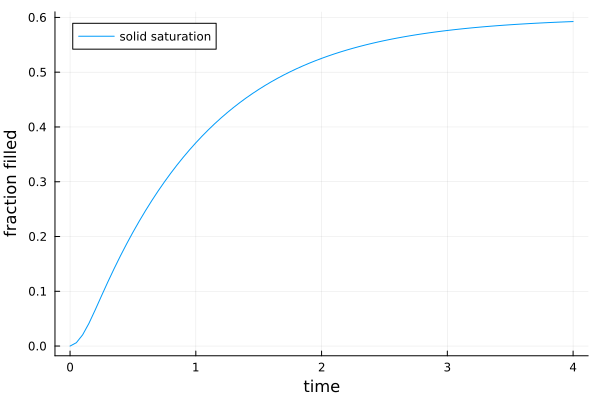

In [165]:
# We calculate the FE integration weights for rho_s.
#
# The mass matrix is:
#
#     M_ij = ∫ phi_i * phi_j dx
#
# Multiplying it by a vector of ones gives:
#
#     b_i = Σ_j M_ij = ∫ phi_i dx
#
# which is the correct FE weight for integrating the solution:
#
#     ∫ rho_s dx ≈ b ⋅ rho_s
#
# This automatically handles the dx/2 boundary contributions
# for P1 elements and also works for nonuniform meshes.
M_rho_s = M[rho_s_global, rho_s_global]
mass_weights_rho_s = M_rho_s * ones(length(rho_s_global))


# Calculate total absorbed amount at every saved timestep
absorbed_mass = zeros(size(sol_ρ_s, 2))

for k in axes(sol_ρ_s, 2)

    # FE approximation of:
    #
    #     M_s(t) = ∫ rho_s(x,t) dx
    #
    absorbed_mass[k] = dot(mass_weights_rho_s, sol_ρ_s[:, k])

end


# Maximum possible absorbed mass:
#
#     M_sat = ∫ rho_sat dx = rho_sat * L
#
# Here L = 1, but keeping the formula general.

maximum_mass = rho_sat * 1.0


# Fraction of solid capacity filled
fill_fraction = absorbed_mass ./ maximum_mass


# Plot filling fraction versus time
plot(
    discrete_t,
    fill_fraction,
    xlabel = "time",
    ylabel = "fraction filled",
    label = "solid saturation",
)

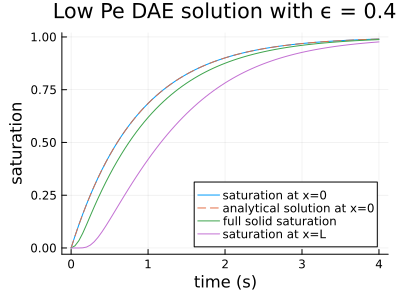

In [192]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    title = "Low Pe DAE solution with ϵ = $(ϵ)",
    legend=:bottomright,
    size=(400,300)
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [193]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_2_result_low_Pe_DAE.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_2_result_low_Pe_DAE.png"

In [196]:
display(anim)

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_eEKXHW", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000072.png", "000073.png", "000074.png", "000075.png", "000076.png", "000077.png", "000078.png", "000079.png", "000080.png", "000081.png"])

In [225]:
savefig(joinpath(foldername, "fill_fraction.png"))

"c:\\Users\\noudh\\uni\\MEP\\Model 2\\c. dae\\fill_fraction.png"